# Name = TAKSH SAMIRKUMAR PATEL
# Major_Project = Hierarchical Clustering for Customer Data

In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

In [26]:
project_path = os.getcwd()
file_path = project_path + '/Wholesale customers data.csv'
df = pd.read_csv(file_path)
df

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


# Basic EDA

In [4]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [5]:
df.tail()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125
439,1,3,2787,1698,2510,65,477,52


In [6]:
df.shape

(440, 8)

In [10]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
df.describe

<bound method NDFrame.describe of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  

In [9]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

# Feature Scaling and Model Building

In [14]:
X = df.drop(columns = ['Region','Channel'])

In [15]:
X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...
435,29703,12051,16027,13135,182,2204
436,39228,1431,764,4510,93,2346
437,14531,15488,30243,437,14841,1867
438,10290,1981,2232,1038,168,2125


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

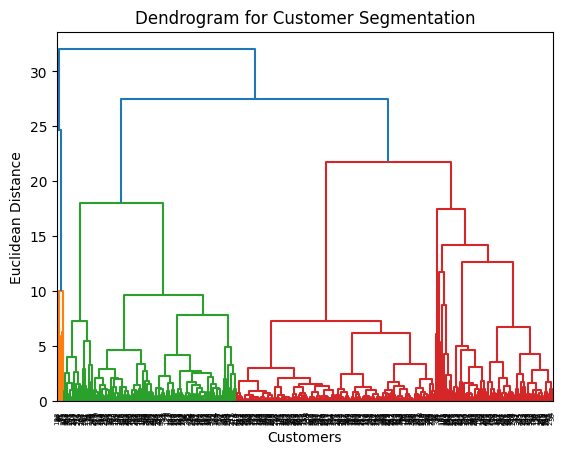

In [17]:
linked = linkage(X_scaled, method='ward')
plt.figure()
dendrogram(linked)
plt.title("Dendrogram for Customer Segmentation")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [18]:
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
df["Cluster"] = model.fit_predict(X_scaled)

In [19]:
df.groupby("Cluster").mean()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,,,
0,1.833333,2.833333,27477.000000,43542.166667,54588.500000,8285.666667,25018.333333,10247.833333
1,1.085409,2.533808,15048.932384,3017.298932,3791.761566,3837.316726,758.007117,1309.900356
2,1.738562,2.549020,5794.241830,9419.888889,13761.738562,1461.764706,5913.379085,1577.607843


In [21]:
cluster_centers = df.drop(columns=["Channel", "Region"]).groupby("Cluster").mean()
cluster_centers

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,27477.000000,43542.166667,54588.500000,8285.666667,25018.333333,10247.833333
1,15048.932384,3017.298932,3791.761566,3837.316726,758.007117,1309.900356
2,5794.241830,9419.888889,13761.738562,1461.764706,5913.379085,1577.607843


# One Prediction of Cluster

In [27]:
new_customer = np.array([[8000, 6000, 9000, 2000, 3000, 1500]])


new_customer_scaled = scaler.transform(new_customer)


distances = cdist(new_customer_scaled, cluster_centers)
predicted_cluster = np.argmin(distances)

print("Predicted Cluster for the new customer:", predicted_cluster)

Predicted Cluster for the new customer: 1


C:\Users\Taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# -------------------------------------------END-----------------------------------------